# Logistic Regression

In [1]:
import numpy as np 
import pandas as pd

In [3]:
df=pd.read_csv('iris.csv')
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# from sklearn.datasets import load_iris

# X,y=load_iris(return_X_y=True)


In [11]:
# from sklearn.datasets import load_iris
# iris=load_iris(as_frame=True)
# iris.frame

In [13]:
X=df.drop(['variety'],axis=1)
y=df['variety']

In [15]:
y.value_counts()

variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

lm=LogisticRegression()
lm.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_test.value_counts()

variety
Virginica     11
Setosa        10
Versicolor     9
Name: count, dtype: int64

In [24]:
print(lm.classes_)

['Setosa' 'Versicolor' 'Virginica']


In [27]:
y_pred=lm.predict(X_test)

In [29]:
y_pred

array(['Versicolor', 'Setosa', 'Virginica', 'Versicolor', 'Versicolor',
       'Setosa', 'Versicolor', 'Virginica', 'Versicolor', 'Versicolor',
       'Virginica', 'Setosa', 'Setosa', 'Setosa', 'Setosa', 'Versicolor',
       'Virginica', 'Versicolor', 'Versicolor', 'Virginica', 'Setosa',
       'Virginica', 'Setosa', 'Virginica', 'Virginica', 'Virginica',
       'Virginica', 'Virginica', 'Setosa', 'Setosa'], dtype=object)

In [32]:
from sklearn.metrics import accuracy_score
acc_sc=accuracy_score(y_test,y_pred)*100

In [34]:
acc_sc

100.0

In [36]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



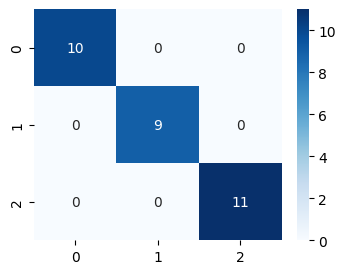

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,cmap='Blues')
plt.show()

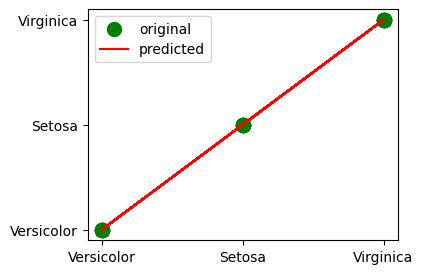

In [39]:
plt.figure(figsize=(4,3))
plt.scatter(y_test,y_pred,c='g',s=100,label='original')
plt.plot(y_test,y_test,c='r',label='predicted')
plt.legend()
plt.show()

In [42]:
print("Train Accuracy:", lm.score(X_train, y_train))
print("Test Accuracy:", lm.score(X_test, y_test))


Train Accuracy: 0.975
Test Accuracy: 1.0


# Decision Tree Classifier

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

tre=DecisionTreeClassifier()
tre.fit(X_train_scaled,y_train)
y_tre_pred=tre.predict(X_test_scaled)

In [47]:
y_tre_pred

array(['Versicolor', 'Setosa', 'Virginica', 'Versicolor', 'Versicolor',
       'Setosa', 'Versicolor', 'Virginica', 'Versicolor', 'Versicolor',
       'Virginica', 'Setosa', 'Setosa', 'Setosa', 'Setosa', 'Versicolor',
       'Virginica', 'Versicolor', 'Versicolor', 'Virginica', 'Setosa',
       'Virginica', 'Setosa', 'Virginica', 'Virginica', 'Virginica',
       'Virginica', 'Virginica', 'Setosa', 'Setosa'], dtype=object)

In [49]:
tre_acc=accuracy_score(y_test,y_tre_pred)

In [51]:
tre_acc

1.0

In [53]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_tre_pred))
print(classification_report(y_test,y_tre_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



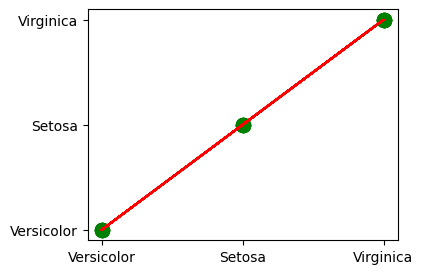

In [55]:
plt.figure(figsize=(4,3))
plt.scatter(y_test,y_tre_pred,c='g',s=100)
plt.plot(y_test,y_test,c='r')
plt.show()

In [57]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tre.feature_importances_
})

print(feature_importance.sort_values(by='Importance', ascending=False))

        Feature  Importance
2  petal.length    0.906143
3   petal.width    0.077186
1   sepal.width    0.016670
0  sepal.length    0.000000


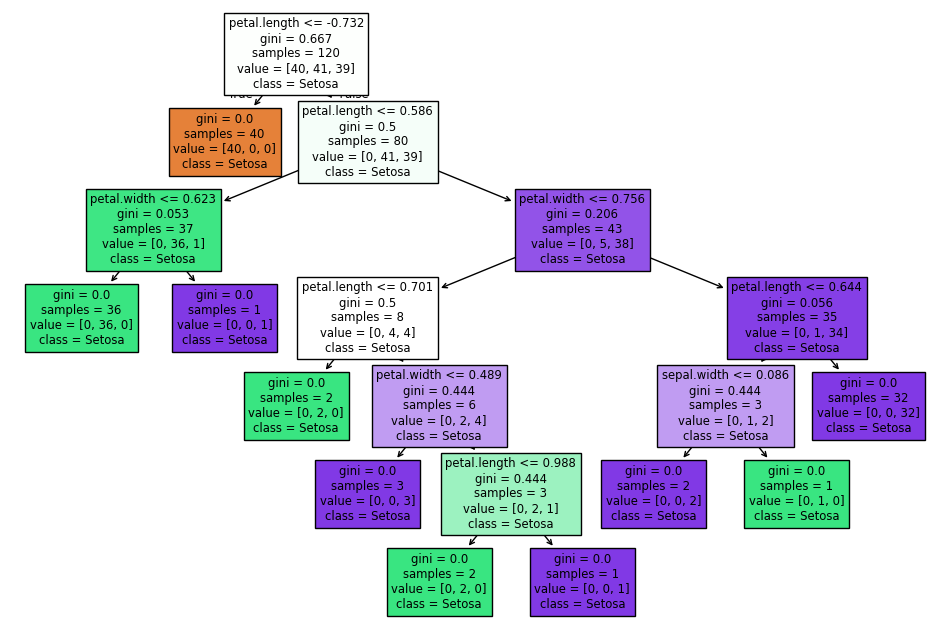

In [59]:
plt.figure(figsize=(12,8))
from sklearn.tree import plot_tree
plot_tree(tre,feature_names=X.columns,class_names=y,filled=True)
plt.show()

In [60]:
print(f'testing score{tre.score(X_train_scaled,y_train)}')
print(f'testing score{tre.score(X_test_scaled,y_test)}')

testing score1.0
testing score1.0


In [61]:
dt_model = DecisionTreeClassifier(
    max_depth=3,        # limit depth
    min_samples_split=5,
    random_state=42
)

# Random Forest Classifier

In [66]:
from sklearn.ensemble import RandomForestClassifier

rft=RandomForestClassifier(n_estimators=100)
rft.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
y_rmf_prd=rft.predict(X_test_scaled)

In [70]:
rdm_acc=accuracy_score(y_test,y_rmf_prd)

In [72]:
rdm_acc

1.0

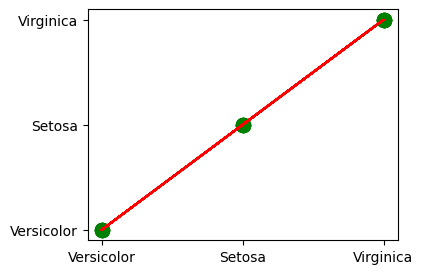

In [74]:
plt.figure(figsize=(4,3))
plt.scatter(y_test,y_rmf_prd,c='g',s=100)
plt.plot(y_test,y_test,c='r')
plt.show()

In [75]:
print(f'testing score{rft.score(X_train_scaled,y_train)}')
print(f'testing score{rft.score(X_test_scaled,y_test)}')

testing score1.0
testing score1.0


In [78]:
# RandomForestClassifier(
#     n_estimators=100,     # number of trees
#     max_depth=None,       # tree depth
#     max_features='sqrt',  # features per split
#     random_state=42
# )

# K-Nearest Neighbour Classifier(KNN)

In [81]:
from sklearn.neighbors import KNeighborsClassifier

kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(X_train_scaled,y_train)
y_kn_prd=kn.predict(X_test_scaled)

In [83]:
kn_acc=accuracy_score(y_test,y_kn_prd)

In [85]:
kn_acc

1.0

Train Accuracy: 0.9416666666666667
Test Accuracy: 1.0


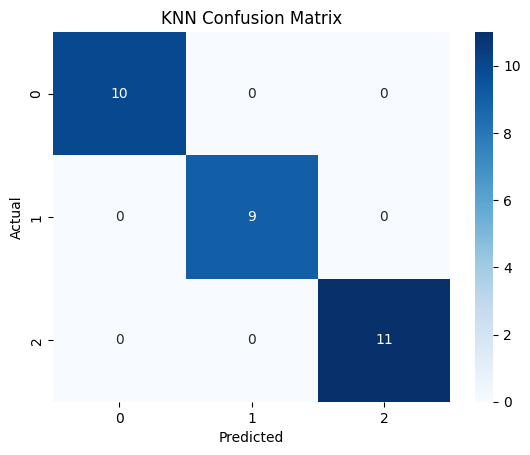

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Train Accuracy:", kn.score(X_train_scaled, y_train))
print("Test Accuracy:", kn.score(X_test_scaled, y_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_kn_prd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

In [88]:
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"K={k}, Accuracy={acc:.4f}")

K=1, Accuracy=1.0000
K=2, Accuracy=1.0000
K=3, Accuracy=1.0000
K=4, Accuracy=1.0000
K=5, Accuracy=1.0000
K=6, Accuracy=1.0000
K=7, Accuracy=1.0000
K=8, Accuracy=1.0000
K=9, Accuracy=1.0000
K=10, Accuracy=1.0000


# SVM

In [92]:
from sklearn.svm import SVC

sv=SVC(kernel='rbf')
sv.fit(X_train_scaled,y_train)
y_sv_prd=sv.predict(X_test_scaled)


In [94]:
sv_acc=accuracy_score(y_test,y_sv_prd)
sv_acc

1.0

Train Accuracy: 0.9666666666666667
Test Accuracy: 1.0


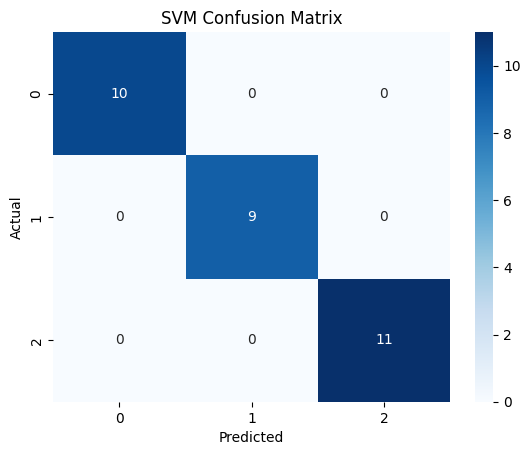

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Train Accuracy:", sv.score(X_train_scaled, y_train))
print("Test Accuracy:", sv.score(X_test_scaled, y_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_sv_prd)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

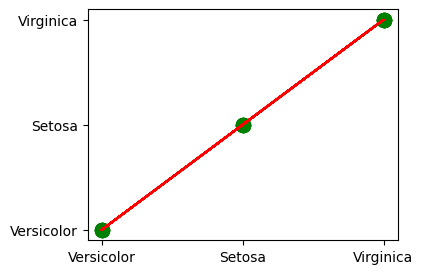

In [97]:
plt.figure(figsize=(4,3))
plt.scatter(y_test,y_sv_prd,c='g',s=100)
plt.plot(y_test,y_test,c='r')
plt.show()